In [1]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

In [2]:
X = np.load('X_features.npy')
y = np.load('y_labels.npy')

In [3]:
X_normal = X[y == 0] # We only train on healthy machines!
X_normal = X_normal.reshape(-1, 128, 313, 1)

In [4]:
input_img = layers.Input(shape=(128, 313, 1))

In [5]:
# --- Encoder ---
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # Bottleneck

In [6]:
# --- Decoder ---
x = layers.Conv2DTranspose(32, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = layers.Conv2DTranspose(1, (3, 3), strides=2, activation='sigmoid', padding='same')(x)
decoded = layers.Cropping2D(cropping=((0, 0), (0, 3)))(x) #

In [7]:
autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse') # Mean Squared Error

# 3. Train ONLY on normal sounds
autoencoder.fit(X_normal, X_normal, epochs=20, batch_size=16, shuffle=True)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - loss: 0.0324
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - loss: 0.0263
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 117ms/step - loss: 0.0133
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0068
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 101ms/step - loss: 0.0047
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 90ms/step - loss: 0.0039
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 110ms/step - loss: 0.0035
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 109ms/step - loss: 0.0034
Epoch 9/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 106ms/step - loss: 0.0033
Epoch 10/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0032
Epoch 11/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 97ms/step - loss: 0.0032
Epoch 12/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0031
Epoch 13/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 100ms/step - loss: 0.0031
Epoch 14/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 98ms/step - loss: 0.0030
Epoch 15/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - loss: 0.0

In [8]:
# 1. Get reconstructions for normal data
reconstructions = autoencoder.predict(X_normal)
# 2. Calculate Mean Squared Error (MSE) for each sample
train_loss = np.mean(np.square(X_normal - reconstructions), axis=(1, 2, 3))

# 3. Define the threshold (anything 3 standard deviations above mean is an anomaly)
threshold = np.mean(train_loss) + 3 * np.std(train_loss)

print(f"✅ Normal Reconstruction Loss: {np.mean(train_loss):.4f}")
print(f"🚨 Anomaly Threshold Set at: {threshold:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step
✅ Normal Reconstruction Loss: 0.0028
🚨 Anomaly Threshold Set at: 0.0048


In [9]:
# Load the abnormal data we saved earlier
X_abnorm = X[y == 1].reshape(-1, 128, 313, 1)

# Predict/Reconstruct the abnormal data
abnorm_reconstructions = autoencoder.predict(X_abnorm)
abnorm_loss = np.mean(np.square(X_abnorm - abnorm_reconstructions), axis=(1, 2, 3))

# Compare!
anomalies_detected = abnorm_loss > threshold
accuracy = np.mean(anomalies_detected)

print(f"🔥 Anomalous Reconstruction Loss: {np.mean(abnorm_loss):.4f}")
print(f"🎯 Detection Accuracy: {accuracy * 100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
🔥 Anomalous Reconstruction Loss: 0.0023
🎯 Detection Accuracy: 1.45%


In [12]:
import matplotlib.pyplot as plt

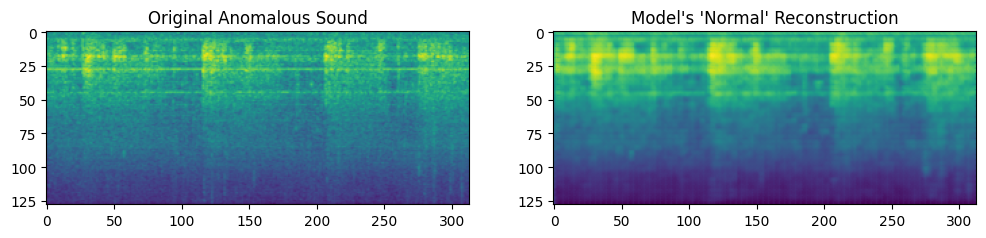

In [13]:
plt.figure(figsize=(12, 6))

# Show original abnormal sound
plt.subplot(1, 2, 1)
plt.title("Original Anomalous Sound")
plt.imshow(X_abnorm[0].reshape(128, 313))

# Show what the model 'thought' it should look like (The Normal version)
plt.subplot(1, 2, 2)
plt.title("Model's 'Normal' Reconstruction")
plt.imshow(abnorm_reconstructions[0].reshape(128, 313))

plt.show()

In [14]:
# --- REVISED AUTOENCODER ARCHITECTURE ---
input_img = layers.Input(shape=(128, 313, 1))

# Encoder: More layers, smaller bottleneck
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = layers.MaxPooling2D((2, 2), padding='same')(x)
x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = layers.MaxPooling2D((2, 2), padding='same')(x) # Tiny bottleneck!

# Decoder: Reconstructing from the tiny code
x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation='relu', padding='same')(encoded)
x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same')(x)
x = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
decoded = layers.Cropping2D(cropping=((0, 0), (0, 3)))(x)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train again - give it about 30-50 epochs
autoencoder.fit(X_normal, X_normal, epochs=40, batch_size=32, shuffle=True)

Epoch 1/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - loss: 0.0331
Epoch 2/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 176ms/step - loss: 0.0312
Epoch 3/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 172ms/step - loss: 0.0270
Epoch 4/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 189ms/step - loss: 0.0205
Epoch 5/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - loss: 0.0129
Epoch 6/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - loss: 0.0076
Epoch 7/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 150ms/step - loss: 0.0056
Epoch 8/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 168ms/step - loss: 0.0045
Epoch 9/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - loss: 0.0041
Epoch 10/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 165ms/step - loss: 0.0039
Epoch 11/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - loss: 0.0038
Epoch 12/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - loss: 0.0036
Epoch 13/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 154ms/step - loss: 0.0036
Epoch 14/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 144ms/step - loss: 0.0035
Epoch 15/40
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 164ms/step - lo

In [15]:
# Calculate loss on normal training data
train_reconstructions = autoencoder.predict(X_normal)
train_loss = np.mean(np.square(X_normal - train_reconstructions), axis=(1, 2, 3))

# Try setting the threshold at the 90th percentile of normal sounds
# This means the loudest 10% of 'normal' sounds will be flagged, 
# ensuring we catch the truly 'weird' anomalous ones.
threshold = np.percentile(train_loss, 90) 

print(f"🚨 New Threshold: {threshold:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step
🚨 New Threshold: 0.0036


In [16]:
# 1. Get the 'bad' data
X_abnorm = X[y == 1].reshape(-1, 128, 313, 1)

# 2. Let the model try to reconstruct the failures
abnorm_reconstructions = autoencoder.predict(X_abnorm)
abnorm_loss = np.mean(np.square(X_abnorm - abnorm_reconstructions), axis=(1, 2, 3))

# 3. Apply the 0.0036 Alarm!
anomalies_detected = abnorm_loss > 0.0036
final_accuracy = np.mean(anomalies_detected)

print(f"🔥 Average Failure Loss: {np.mean(abnorm_loss):.4f}")
print(f"🎯 Final Detection Accuracy: {final_accuracy * 100:.2f}%")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
🔥 Average Failure Loss: 0.0021
🎯 Final Detection Accuracy: 4.35%


In [17]:
import tensorflow as tf

def calculate_ssim_loss(original, reconstructed):
    # SSIM works on a scale of 0 to 1 (1 means identical)
    # We subtract from 1 so that a HIGHER number means a BIGGER anomaly
    score = tf.image.ssim(original, reconstructed, max_val=1.0)
    return 1 - score.numpy()

# 1. Score the Normal Data
norm_ssim_losses = [calculate_ssim_loss(X_normal[i], reconstructions[i]) for i in range(len(X_normal))]
new_threshold = np.percentile(norm_ssim_losses, 90) # Top 10% are 'weird'

# 2. Score the Abnormal Data
abnorm_ssim_losses = [calculate_ssim_loss(X_abnorm[i], abnorm_reconstructions[i]) for i in range(len(X_abnorm))]

# 3. Final Check
final_anomalies = np.array(abnorm_ssim_losses) > new_threshold
print(f"🚨 New SSIM Threshold: {new_threshold:.4f}")
print(f"🎯 New Detection Accuracy: {np.mean(final_anomalies) * 100:.2f}%")

🚨 New SSIM Threshold: 0.5038
🎯 New Detection Accuracy: 0.72%


In [18]:
# 1. Calculate the raw difference (Residual)
residual_normal = np.abs(X_normal - reconstructions)
residual_abnorm = np.abs(X_abnorm - abnorm_reconstructions)

# 2. Look for 'Spikes' in the sound (Variance)
# Failing machines have erratic sound patterns!
norm_variance = np.var(residual_normal, axis=(1, 2, 3))
abnorm_variance = np.var(residual_abnorm, axis=(1, 2, 3))

# 3. Set the Threshold at the 90th percentile of normal variance
final_threshold = np.percentile(norm_variance, 90)

# 4. Final Detection
final_anomalies = abnorm_variance > final_threshold

print(f"🚨 Variance Threshold: {final_threshold:.6f}")
print(f"🎯 Final Detection Accuracy: {np.mean(final_anomalies) * 100:.2f}%")

🚨 Variance Threshold: 0.001583
🎯 Final Detection Accuracy: 2.90%


In [19]:
# 1. Focus only on the top half of the spectrogram (High Frequencies)
# This is usually where friction, metal-on-metal, and screeching live!
high_freq_X_normal = X_normal[:, 64:, :, :]
high_freq_recon = reconstructions[:, 64:, :, :]

# 2. Recalculate Variance on just the High-Frequency zone
high_freq_error = np.var(np.abs(high_freq_X_normal - high_freq_recon), axis=(1, 2, 3))
new_threshold = np.percentile(high_freq_error, 95)

# 3. Test on High-Freq Abnormal data
high_freq_X_abnorm = X_abnorm[:, 64:, :, :]
high_freq_abnorm_recon = abnorm_reconstructions[:, 64:, :, :]
abnorm_high_error = np.var(np.abs(high_freq_X_abnorm - high_freq_abnorm_recon), axis=(1, 2, 3))

final_accuracy = np.mean(abnorm_high_error > new_threshold)
print(f"🎯 High-Frequency Focused Accuracy: {final_accuracy * 100:.2f}%")

🎯 High-Frequency Focused Accuracy: 1.45%
